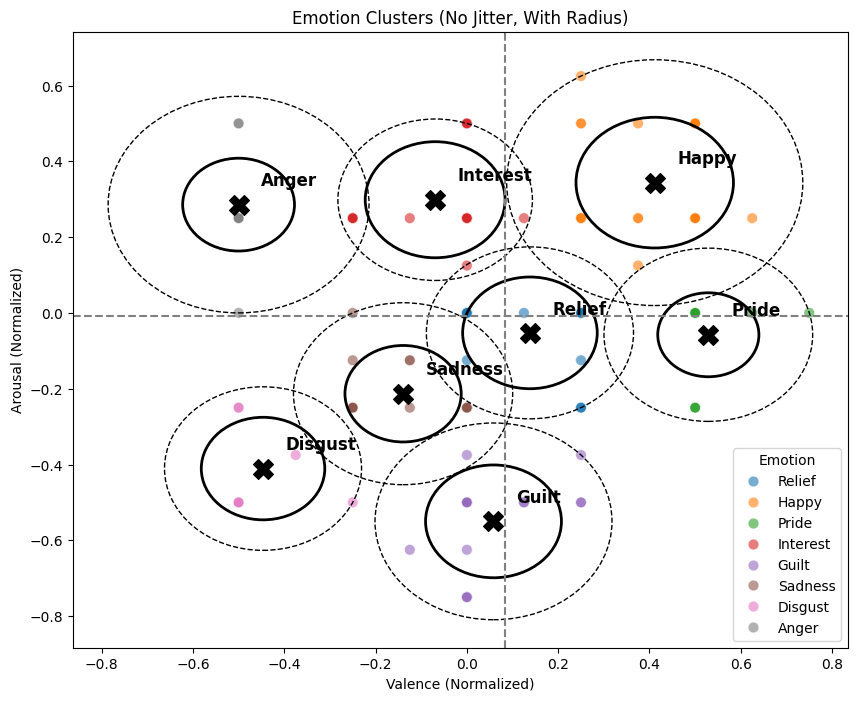

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle
import numpy as np

# 1. Load saved CSV
va_data = pd.read_csv('mapped_emotions_data.csv')

# 2. Recompute centroids
centroids = va_data.groupby('Cluster')[['Q2_Valence', 'Q2_Arousal']].mean().values

# 3. Recompute center
center_v = va_data['Q2_Valence'].mean()
center_a = va_data['Q2_Arousal'].mean()

# 4. Recompute cluster stats
cluster_stats = {}

for cluster_idx in range(8):
    cluster_points = va_data[
        va_data['Cluster'] == cluster_idx
    ][['Q2_Valence', 'Q2_Arousal']].values
    
    if len(cluster_points) > 0:
        centroid = centroids[cluster_idx]
        distances = np.linalg.norm(cluster_points - centroid, axis=1)
        
        cluster_stats[cluster_idx] = {
            'mean': np.mean(distances),
            'max': np.max(distances)
        }
    else:
        cluster_stats[cluster_idx] = {'mean': 0, 'max': 0}

# 5. Plot WITHOUT radius (no jitter)
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=va_data,
    x='Q2_Valence',
    y='Q2_Arousal',
    hue='Emotion',
    palette='tab10',
    alpha=0.6,
    s=60
)

for i, centroid in enumerate(centroids):
    emotion = va_data[va_data['Cluster'] == i]['Emotion'].iloc[0]
    
    plt.scatter(centroid[0], centroid[1], c='black', marker='X', s=200)
    
    plt.text(
        centroid[0] + 0.05,
        centroid[1] + 0.05,
        emotion,
        fontsize=12,
        weight='bold'
    )

plt.axvline(center_v, color='gray', linestyle='--')
plt.axhline(center_a, color='gray', linestyle='--')

plt.title('Emotion Clusters (No Jitter, No Radius)')
plt.xlabel('Valence (Normalized)')
plt.ylabel('Arousal (Normalized)')

plt.savefig('emotion_clusters_no_jitter.png',
            dpi=300, bbox_inches='tight')

plt.close()


# 6. Plot WITH radius (no jitter)
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=va_data,
    x='Q2_Valence',
    y='Q2_Arousal',
    hue='Emotion',
    palette='tab10',
    alpha=0.6,
    s=60
)

for i, centroid in enumerate(centroids):
    emotion = va_data[va_data['Cluster'] == i]['Emotion'].iloc[0]
    stats = cluster_stats[i]
    
    x, y = centroid

    # centroid
    plt.scatter(x, y, c='black', marker='X', s=200)
    
    plt.text(x + 0.05, y + 0.05, emotion, fontsize=12, weight='bold')

    # mean radius
    plt.gca().add_patch(Circle((x, y), stats['mean'], fill=False, linewidth=2))

    # max radius
    plt.gca().add_patch(Circle((x, y), stats['max'], fill=False, linestyle='dashed'))

plt.axvline(center_v, color='gray', linestyle='--')
plt.axhline(center_a, color='gray', linestyle='--')

plt.title('Emotion Clusters (No Jitter, With Radius)')
plt.xlabel('Valence (Normalized)')
plt.ylabel('Arousal (Normalized)')
plt.savefig('emotion_clusters_no_jitter_with_radius.png',
            dpi=300, bbox_inches='tight')
plt.show()

plt.close()

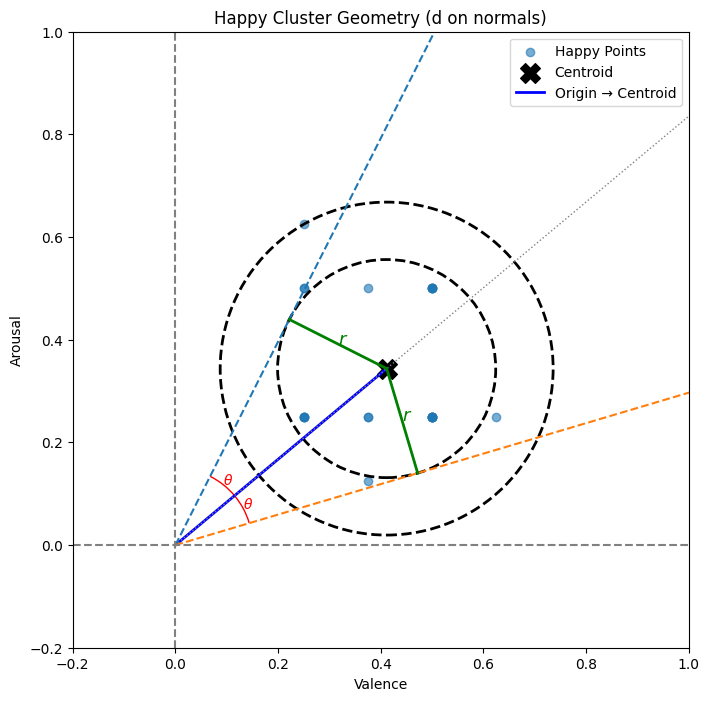

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Arc

# 1. Load CSV
df = pd.read_csv('mapped_emotions_data.csv')

# 2. Filter HAPPY cluster
happy_data = df[df['Emotion'] == 'Happy']

# 3. Centroid
centroid = happy_data[['Q2_Valence', 'Q2_Arousal']].mean().values
cx, cy = centroid

# 4. Radius
points = happy_data[['Q2_Valence', 'Q2_Arousal']].values
radius = 0.4249 / 2

# 5. Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Scatter points
ax.scatter(points[:, 0], points[:, 1], alpha=0.6, label='Happy Points')

# Centroid
ax.scatter(cx, cy, c='black', marker='X', s=200, label='Centroid')

# Circles
circle = Circle((cx, cy), radius, fill=False, linestyle='dashed', linewidth=2)
max_circle = Circle((cx, cy), 0.3243, fill=False, linestyle='dashed', linewidth=2)

ax.add_patch(max_circle)
ax.add_patch(circle)

# Origin
ox, oy = 0, 0

# Distance from origin
d = np.sqrt(cx**2 + cy**2)

# Angle to centroid
theta = np.arctan2(cy, cx)

# Line from origin to centroid
ax.plot([ox, cx], [oy, cy], linewidth=2, color='blue', label='Origin → Centroid')

# Extend direction line
L = 1.5
ax.plot(
    [ox, L * np.cos(theta)],
    [oy, L * np.sin(theta)],
    linewidth=1,
    linestyle=':',
    color='gray'
)

# Tangents + Normals
if d > radius:
    alpha = np.arcsin(radius / d)

    t1 = theta + alpha
    t2 = theta - alpha

    # Tangents
    ax.plot([ox, L*np.cos(t1)], [oy, L*np.sin(t1)], linestyle='--' )
    ax.plot([ox, L*np.cos(t2)], [oy, L*np.sin(t2)], linestyle='--')

    # Tangent points
    length_to_tangent = np.sqrt(d**2 - radius**2)

    tx1 = length_to_tangent * np.cos(t1)
    ty1 = length_to_tangent * np.sin(t1)

    tx2 = length_to_tangent * np.cos(t2)
    ty2 = length_to_tangent * np.sin(t2)

    # Normals (tangent point → center)
    ax.plot([tx1, cx], [ty1, cy], color='green', linewidth=2)
    ax.plot([tx2, cx], [ty2, cy], color='green', linewidth=2)

    # Label "d" on normals
    ax.text((tx1+cx)/2, (ty1+cy)/2, r'$r$', color='green', fontsize=13)
    ax.text((tx2+cx)/2, (ty2+cy)/2, r'$r$', color='green', fontsize=13)

    # Mark tangent points
    # ax.scatter([tx1, tx2], [ty1, ty2], color='purple', zorder=5)

    # Angle arcs
    arc_radius = 0.3

    arc1 = Arc((0, 0), arc_radius, arc_radius,
               angle=0,
               theta1=np.degrees(theta),
               theta2=np.degrees(t1),
               color='red')

    arc2 = Arc((0, 0), arc_radius, arc_radius,
               angle=0,
               theta1=np.degrees(t2),
               theta2=np.degrees(theta),
               color='red')

    ax.add_patch(arc1)
    ax.add_patch(arc2)

    # Theta labels
    mid_angle1 = (theta + t1) / 2
    mid_angle2 = (theta + t2) / 2

    ax.text(0.15*np.cos(mid_angle1), 0.15*np.sin(mid_angle1), r'$\theta$', color='red')
    ax.text(0.15*np.cos(mid_angle2), 0.15*np.sin(mid_angle2), r'$\theta$', color='red')

else:
    print("Tangents do not exist")

# Axes
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

ax.set_xlim(-0.2, 1)
ax.set_ylim(-0.2, 1)

ax.set_title('Happy Cluster Geometry (d on normals)')
ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')

ax.set_aspect('equal')
ax.legend()

plt.savefig('happy_cluster_with_r_on_normals.png', dpi=300, bbox_inches='tight')
plt.show()